In [1]:
# ===== BLOCO 1: IMPORTAÇÃO DE BIBLIOTECAS =====
# Importa bibliotecas necessárias para análise de dados e visualização

import pandas as pd                # Manipulação e análise de dados em DataFrames
import matplotlib.pyplot as plt    # Criação de gráficos e visualizações
import seaborn as sns             # Visualizações avançadas (baseado em matplotlib)
import yfinance as yf             # Download de dados financeiros de ações
import numpy as np                 # Operações numéricas e arrays

In [2]:
# ===== BLOCO 2: DOWNLOAD DE DADOS HISTÓRICOS =====
# Obtém cotações de ações e do índice Ibovespa para análise

# Lista de tickers (símbolos) das ações a serem analisadas
tickers = ["VALE3.SA", "ITSA4.SA", "BBAS3.SA", "PSSA3.SA", "^BVSP"]
# VALE3.SA: Vale (mineração), ITSA4.SA: Itaú (banco), BBAS3.SA: Banco do Brasil (banco),
# PSSA3.SA: Porto Seguro (seguros), ^BVSP: Índice Bovespa (referência do mercado)

# Faz download dos últimos 10 anos de preços de fechamento (Close) para cada ticker
dados = yf.download(tickers, period="10y")["Close"]

# Exibe os dados baixados (primeiras linhas do DataFrame)
dados

[*********************100%***********************]  5 of 5 completed


Ticker,BBAS3.SA,ITSA4.SA,PSSA3.SA,VALE3.SA,^BVSP
Date,,,,,
2016-04-18,5.936436,2.600654,8.773893,9.418569,52894.00000
2016-04-19,5.909551,2.597610,8.646357,10.115694,53710.00000
2016-04-20,5.869221,2.545903,8.486936,10.758429,53631.00000
2016-04-22,5.718658,2.521569,8.681138,9.557006,52908.00000
2016-04-25,5.592296,2.494192,7.968098,8.929100,51862.00000
...,...,...,...,...,...
2026-04-10,24.730000,14.810000,53.230000,85.589996,197324.00000
2026-04-13,24.750000,14.710000,53.619999,87.360001,198001.00000
2026-04-14,25.379999,14.830000,52.360001,88.300003,198657.00000


<Axes: title={'center': 'Desempenho Relativo vs Ibovespa'}, xlabel='Date'>

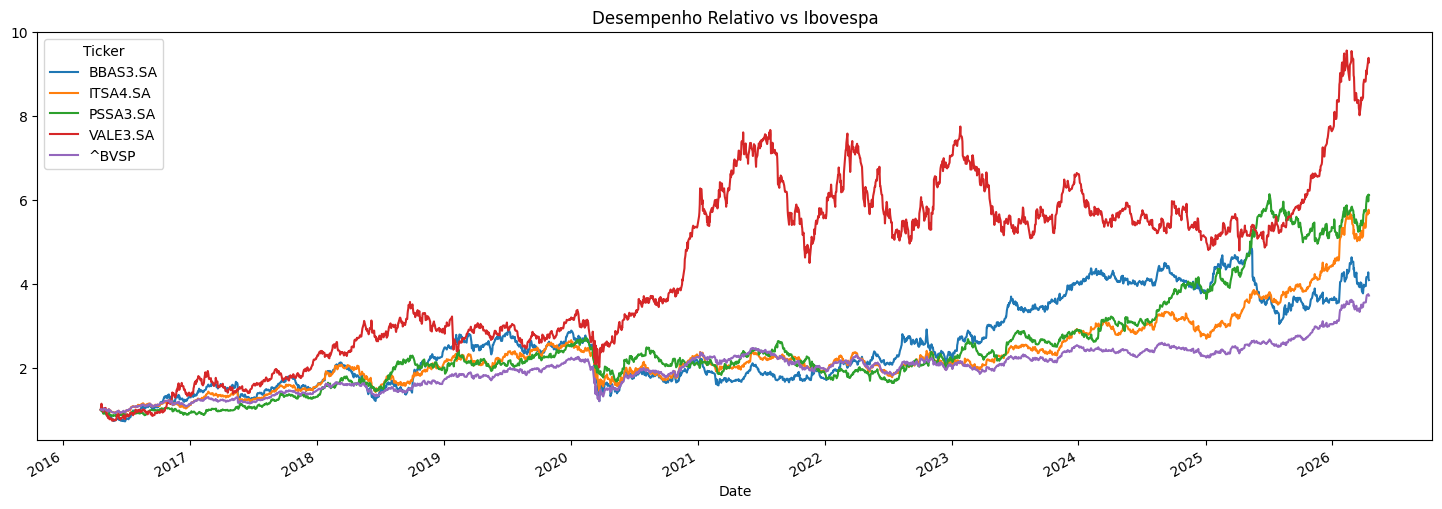

In [3]:
# ===== BLOCO 3: NORMALIZAÇÃO E DESEMPENHO RELATIVO =====
# Compara o desempenho de cada ação em relação ao seu valor inicial

# Divide todos os preços pelo primeiro preço de cada ação (normalização)
# Isso faz com que todas as ações comecem com valor 1.0 (ou 100%)
dados_normalizados = dados / dados.iloc[0]

# *** GRÁFICO 1: DESEMPENHO RELATIVO VS IBOVESPA ***
# Este gráfico mostra como cada ação variou ao longo do tempo em relação ao seu valor inicial
# Permite comparar visualmente qual ação teve melhor desempenho no período
# Linha mais alta = melhor desempenho, linha mais baixa = pior desempenho
dados_normalizados.plot(
    figsize=(18, 6), 
    title="Desempenho Relativo vs Ibovespa"
)

<Axes: title={'center': 'Retorno Acumulado vs Ibovespa'}, xlabel='Date'>

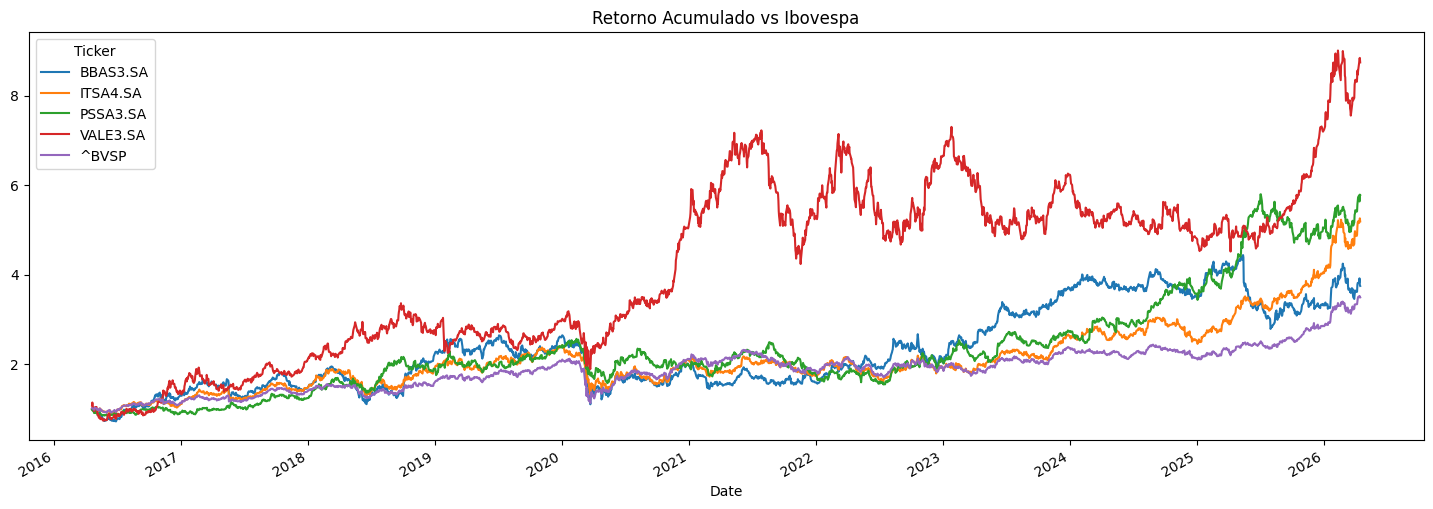

In [4]:
# ===== BLOCO 4: CÁLCULO DE RETORNOS DIÁRIOS E ACUMULADOS =====
# Calcula os retornos (ganhos/perdas percentuais) de cada ação

# Calcula a variação percentual diária (retorno do dia em relação ao dia anterior)
# .dropna() remove valores nulos que resultam da primeira linha não ter dia anterior
retorno = dados.pct_change().dropna()

# Exibe os retornos diários calculados
retorno

# Calcula o retorno acumulado: transforma retornos diários em um crescimento composto
# (1 + retorno) converte retornos em multiplicadores, .cumprod() acumula o produto
# Resultado: mostra como R$ 1 inicial se transforma ao longo do tempo
retorno_acumulado = (1 + retorno).cumprod()

# *** GRÁFICO 2: RETORNO ACUMULADO VS IBOVESPA ***
# Este gráfico mostra o crescimento acumulado de um valor investido no início do período
# Se você investisse R$ 1 em cada ação há 10 anos, este gráfico mostra quanto teria virado
# Linha mais alta = maior lucro acumulado, linha mais baixa = menor lucro ou prejuízo
retorno_acumulado.plot(
    figsize=(18, 6), 
    title="Retorno Acumulado vs Ibovespa"
)

<Axes: title={'center': 'Volatilidade Anualizada'}, xlabel='Ticker'>

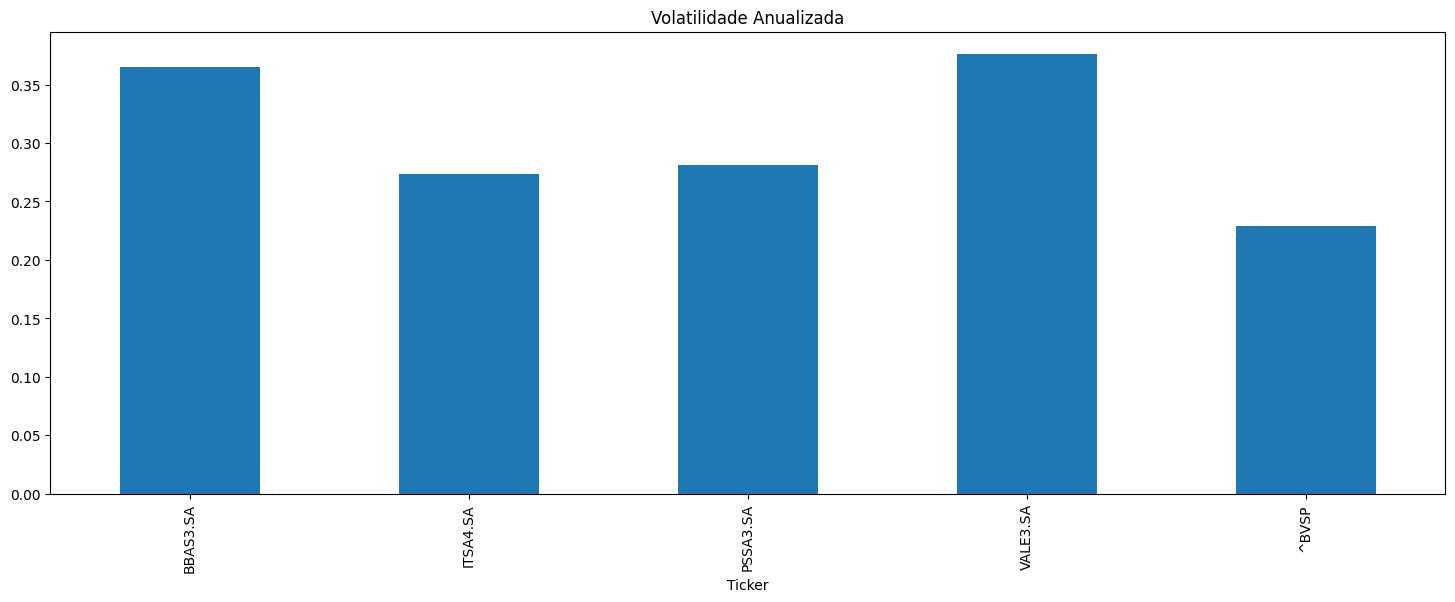

In [5]:
# ===== BLOCO 5: CÁLCULO E VISUALIZAÇÃO DE VOLATILIDADE =====
# Mede o risco (variação) de cada ação

# Calcula o desvio padrão dos retornos diários (medida de dispersão/variação)
# Multiplica por np.sqrt(252) para anualizar a volatilidade (252 = dias úteis no ano)
# Volatilidade alta = ação mais arriscada/instável, Volatilidade baixa = ação mais estável
volatilidade = retorno.std() * np.sqrt(252)

# *** GRÁFICO 3: VOLATILIDADE ANUALIZADA ***
# Gráfico de barras mostrando o risco de cada ação (quanto ela flutua)
# Barras mais altas = maior risco, Barras mais baixas = menor risco
# Útil para investidores escolherem entre ações mais arriscadas ou conservadoras
volatilidade.plot.bar(
    figsize=(18, 6), 
    title="Volatilidade Anualizada"
)

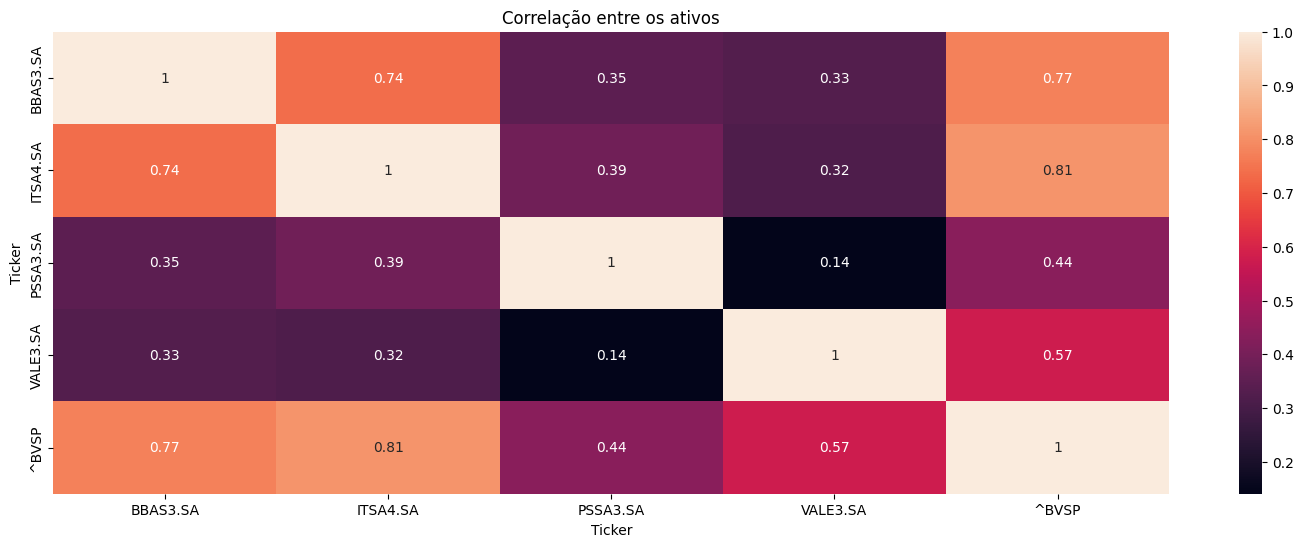

In [6]:
# ===== BLOCO 6: ANÁLISE DE CORRELAÇÃO =====
# Avalia o relacionamento entre os movimentos das ações

# Cria uma figura para o gráfico com tamanho definido
plt.figure(figsize=(18, 6))

# *** GRÁFICO 4: MATRIZ DE CORRELAÇÃO (HEATMAP) ***
# Mostra como as ações se movem em relação umas às outras
# Correlação = 1.0 (verde escuro): ações se movem juntas (mesma direção)
# Correlação = 0.0 (branco): sem relação entre movimentos
# Correlação = -1.0 (vermelho): ações se movem em direções opostas
# annot=True: mostra os valores numéricos dentro de cada célula da matriz
sns.heatmap(retorno.corr(), annot=True)

# Adiciona título ao gráfico
plt.title("Correlação entre os ativos")

# Exibe o gráfico
plt.show()

In [ ]:
# ===== BLOCO 7: RETORNOS MENSAIS =====
# Calcula os retornos percentuais ao final de cada mês

# Reamostra os dados para o último dia útil de cada mês ("MS" = Month Start)
# e calcula a variação percentual mensal, depois multiplica por 100 para obter percentual
retornos_mensais = dados.resample("MS").last().pct_change()*100

# Exibe as primeiras 5 linhas dos retornos mensais calculados
retornos_mensais.head(5)

Ticker,BBAS3.SA,ITSA4.SA,PSSA3.SA,VALE3.SA,^BVSP
Date,,,,,
2016-04-01,NaN,NaN,NaN,NaN,NaN
2016-05-01,-24.918391,-9.307181,-4.693121,-27.780611,-10.088850
2016-06-01,5.179013,6.526338,1.325738,14.416344,6.302608
2016-07-01,22.526160,10.144941,5.046730,13.706155,11.219361
2016-08-01,10.957451,3.813492,-1.957273,-8.432421,1.034760


<Axes: title={'center': 'Retorno Mensal Médio (IBOV)'}, xlabel='Date'>

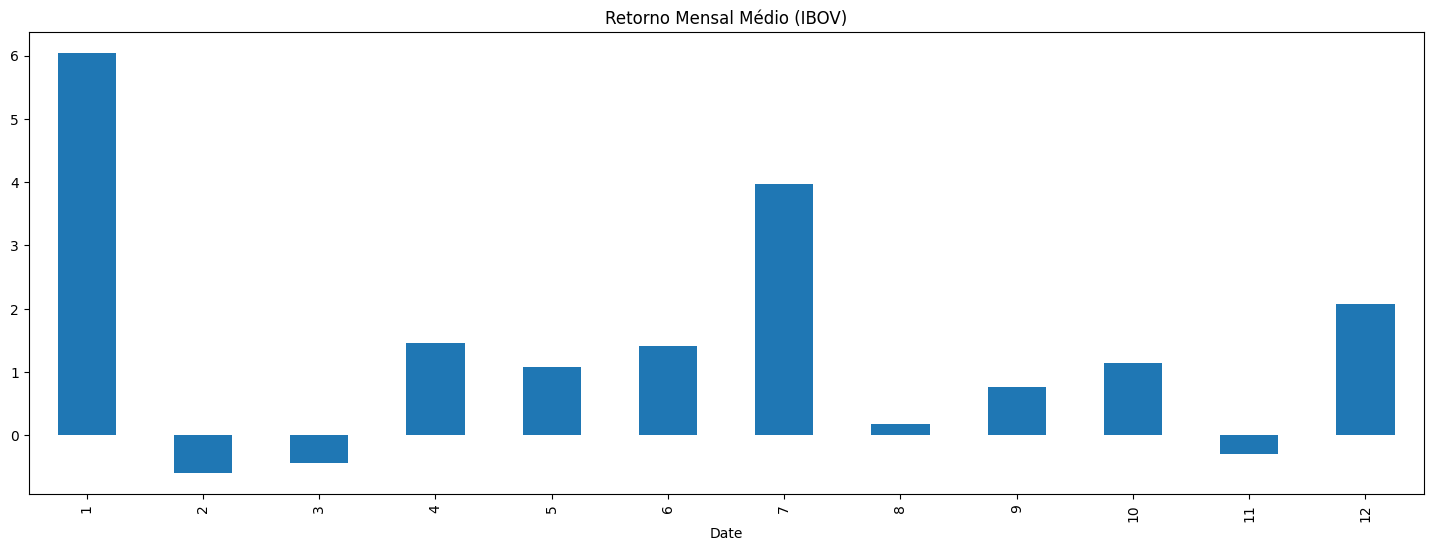

In [ ]:
# ===== BLOCO 8: RETORNOS MENSAIS HISTÓRICOS =====
# Analisa o desempenho médio de cada mês ao longo de todos os anos

# Agrupa os retornos mensais por mês do calendário e calcula a mediana
# (ex: todos os janeiros, todos os fevereriros, etc.)
# A mediana é usada para ser mais resistente a valores extremos
retornos_mensais_historicos = retornos_mensais.groupby(retornos_mensais.index.month).median()

# *** GRÁFICO 5: RETORNO MENSAL MÉDIO DO IBOVESPA ***
# Mostra qual mês do ano teve melhor (ou pior) desempenho historicamente
# Útil para identificar sazonalidade no mercado brasileiro
retornos_mensais_historicos["^BVSP"].plot.bar(
    figsize=(18, 6), title="Retorno Mensal Médio (IBOV)")

In [ ]:
# ===== BLOCO 9: ANÁLISE DE RETORNOS ANUAIS =====
# Calcula os retornos anuais e faz estatísticas sobre anos positivos/negativos

# Reamostra os dados para o último dia útil de cada ano ("YS" = Year Start)
# e calcula a variação percentual anual, depois multiplica por 100 para obter percentual
retornos_anuais = dados.resample("YS").last().pct_change()*100

# Cria um DataFrame com estatísticas sobre os retornos anuais
# "Anos Positivos": conta quantos anos cada ação teve retorno positivo
# "Anos Negativos": conta quantos anos cada ação teve retorno negativo  
# "% Positivos": percentual de anos com retorno positivo
contagem = pd.DataFrame(
    {
        "Anos Positivos": (retornos_anuais > 0).sum(),
        "Anos Negativos": (retornos_anuais < 0).sum(),
        "% Positivos": (retornos_anuais > 0).mean()*100,
    }
)

# Exibe a tabela com as estatísticas calculadas
contagem

,Anos Positivos,Anos Negativos,% Positivos
Ticker,,,
BBAS3.SA,6,4,54.545455
ITSA4.SA,7,3,63.636364
PSSA3.SA,8,2,72.727273
VALE3.SA,8,2,72.727273
^BVSP,8,2,72.727273


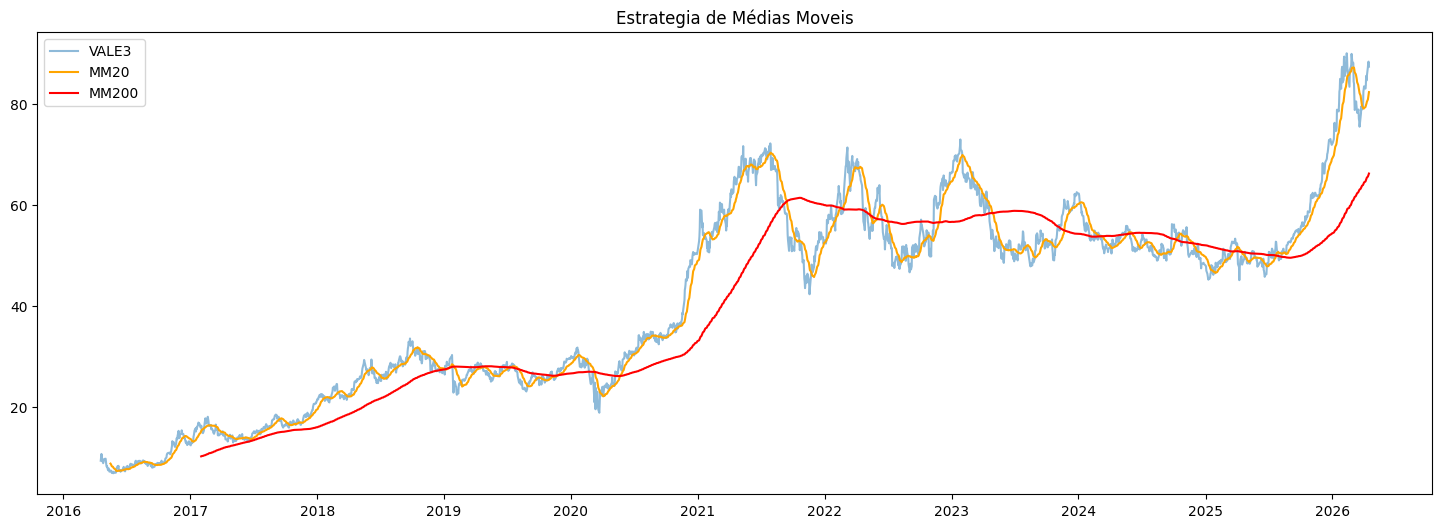

In [ ]:
# ===== BLOCO 10: ESTRATÉGIA DE MÉDIAS MÓVEIS =====
# Implementa uma estratégia de análise técnica usando médias móveis de VALE3

# Cria uma cópia dos dados para não alterar os originais
dados_estrategia = dados.copy()

# Calcula a média móvel de 20 dias (curto prazo - mais responsiva aos movimentos recentes)
dados_estrategia["VALE3_MM20"] = dados_estrategia["VALE3.SA"].rolling(20).mean()

# Calcula a média móvel de 200 dias (longo prazo - identifica tendência geral)
dados_estrategia["VALE3_MM200"] = dados_estrategia["VALE3.SA"].rolling(200).mean()

# *** GRÁFICO 6: ESTRATÉGIA DE MÉDIAS MÓVEIS PARA VALE3 ***
# Visualiza o preço da ação e suas médias móveis para análise técnica
# Quando MM20 cruza para cima da MM200 = possível sinal de compra (tendência de alta)
# Quando MM20 cruza para baixo da MM200 = possível sinal de venda (tendência de baixa)
plt.figure(figsize=(18, 6))
plt.plot(dados_estrategia["VALE3.SA"], label="VALE3", alpha=0.5)        # Preço real (transparente)
plt.plot(dados_estrategia["VALE3_MM20"], label="MM20", color="orange")  # Média móvel de curto prazo
plt.plot(dados_estrategia["VALE3_MM200"], label="MM200", color="red")   # Média móvel de longo prazo
plt.title("Estrategia de Médias Moveis")
plt.legend()
plt.show()